# Ablation IMV — IMDb transformer predictions

This notebook uses the saved predictions produced by the original experiment. It renders figures inline and writes reproducible tables/figures to `results/` and `figures/`.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imv import AblationIMV
from imv.utils import plot_ablation_matrix

ROOT = Path.cwd()
PREDICTIONS = ROOT / "predictions"
FIGURES = ROOT / "figures"
RESULTS = ROOT / "results"
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
VARIANTS = {
    "Original": "imdb_test_predictions_seed_{seed}.csv",
    "3Layers": "imdb_test_predictions_seed_{seed}_layers_3.csv",
    "NoAttention": "imdb_test_predictions_seed_{seed}_no_attention.csv",
    "NoFFN": "imdb_test_predictions_seed_{seed}_no_ffn.csv",
    "NoNorm": "imdb_test_predictions_seed_{seed}_no_layernorm.csv",
}
SEEDS = [42, 43, 44, 45, 46]
RESULT_NAME = "imdb_ablation_imv"

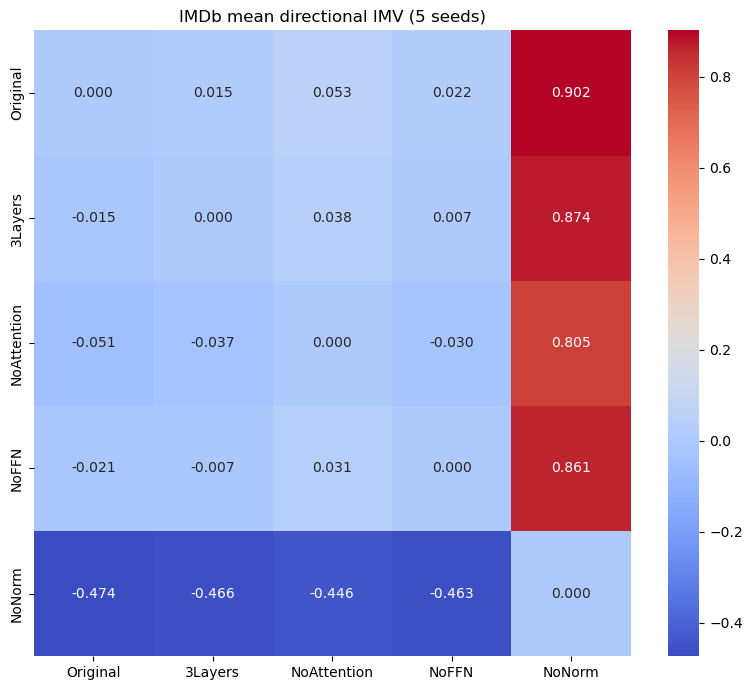

,Original,3Layers,NoAttention,NoFFN,NoNorm
Original,0.000000,0.014810,0.053464,0.021592,0.901545
3Layers,-0.014594,0.000000,0.038088,0.006683,0.873794
NoAttention,-0.050742,-0.036684,0.000000,-0.030248,0.805056
NoFFN,-0.021134,-0.006638,0.031196,0.000000,0.861356
NoNorm,-0.474112,-0.466323,-0.445996,-0.462757,0.000000


In [3]:
matrices = []
for seed in SEEDS:
    frames = {name: pd.read_csv(PREDICTIONS / pattern.format(seed=seed)) for name, pattern in VARIANTS.items()}
    reference = frames["Original"]["True Label"].to_numpy()
    assert all(np.array_equal(frame["True Label"].to_numpy(), reference) for frame in frames.values())
    matrices.append(AblationIMV.calculate_imv_matrix(frames))
mean_matrix = AblationIMV.average_imv_matrices(matrices)
mean_matrix.to_csv(RESULTS / (RESULT_NAME + "_directional.csv"))
fig, ax = plot_ablation_matrix(mean_matrix, figsize=(8, 7), title="IMDb mean directional IMV (5 seeds)")
fig.tight_layout(); fig.savefig(FIGURES / (RESULT_NAME + ".png"), dpi=180, bbox_inches="tight")
plt.show()
mean_matrix

## Legacy discrepancy

The original ablation notebook calculated both directions and then copied the upper triangle onto the lower triangle. That makes the displayed matrix symmetric, although `(w_enhanced-w_basic)/w_basic` is directional. The package result below retains direction. `legacy_symmetric` is saved separately only for exact figure comparison.

In [4]:
legacy_symmetric = mean_matrix.copy()
for i in range(len(legacy_symmetric)):
    for j in range(i + 1, len(legacy_symmetric)):
        legacy_symmetric.iloc[j, i] = legacy_symmetric.iloc[i, j]
legacy_symmetric.to_csv(RESULTS / (RESULT_NAME + "_legacy_symmetric.csv"))
legacy_symmetric

,Original,3Layers,NoAttention,NoFFN,NoNorm
Original,0.000000,0.014810,0.053464,0.021592,0.901545
3Layers,0.014810,0.000000,0.038088,0.006683,0.873794
NoAttention,0.053464,0.038088,0.000000,-0.030248,0.805056
NoFFN,0.021592,0.006683,-0.030248,0.000000,0.861356
NoNorm,0.901545,0.873794,0.805056,0.861356,0.000000
